In [ ]:
import os
import re
import random
from pathlib import Path
from IPython.display import Audio
from tqdm.auto import tqdm
from typing import Optional, Dict, List, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import wordnet

import torch
import librosa
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset


ROOT_DIR = Path.home() / "workspace"
DATA_DIR = ROOT_DIR / "dataset" / "Clotho-v2.1"

In [27]:
from dotenv import load_dotenv
from huggingface_hub import login as hf_login

load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")
hf_login(token=HF_TOKEN)

print("✅ Logged in!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in!


In [2]:
files = list(DATA_DIR.iterdir())  # returns list of Path objects with full paths
files

[PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_evaluation'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_captions_evaluation.csv'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_validation'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_captions_validation.csv'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_captions_development.csv'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_metadata_validation.csv'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_metadata_development.csv'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development'),
 PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_metadata_evaluation.csv')]

In [3]:
caption_path = str(DATA_DIR / "clotho_captions_development.csv")
caption_df = pd.read_csv(caption_path)
caption_df.head()

,file_name,caption_1,caption_2,caption_3,caption_4,caption_5
0,Distorted AM Radio noise.wav,A muddled noise of broken channel of the TV,A television blares the rhythm of a static TV.,Loud television static dips in and out of focus,The loud buzz of static constantly changes pit...,heavy static and the beginnings of a signal on...
1,Paper_Parchment_Rustling.wav,A person is turning a map over and over.,A person is very carefully rapping a gift for ...,A person is very carefully wrapping a gift for...,"He sighed as he turned the pages of the book, ...","papers are being turned, stopped, then turned ..."
2,03 Whales Slowing Down.wav,Several barnyard animals mooing in a barn whil...,"The vocalization of several whales, along with...","Underwater, large numbers of shrimp clicking a...",Whales sing to one another over the flowing wa...,wales sing to one another with water flowing i...
3,Rope tied to boat in port.wav,An office chair is squeaking as someone bends ...,Popping and squeaking gradually tapers off to ...,Someone is opening a creaky door slowly while ...,Squeaking and popping followed by gradual popp...,an office chair is squeaking as someone leans ...
4,carpenter bee.wav,A flying bee is buzzing loudly around an objec...,An annoying fly is buzzing loudly and consiste...,An insect buzzing in the foreground as birds c...,"An insect trapped in a spider web struggles, b...","Outdoors, insect trapped in a spider web and t..."


In [4]:
metadata_path = str(DATA_DIR / "clotho_metadata_development.csv")

metadata_df = pd.read_csv(metadata_path, encoding="ISO-8859-1")
metadata_df.head()

,file_name,keywords,sound_id,sound_link,start_end_samples,manufacturer,license
0,Distorted AM Radio noise.wav,noise;radio,117790,https://freesound.org/people/lavatorius/sounds...,"[139264, 1293089]",lavatorius,http://creativecommons.org/publicdomain/zero/1.0/
1,Paper_Parchment_Rustling.wav,movement;parchment;scroll;crinkle;pages;moving...,204046,https://freesound.org/people/duckduckpony/soun...,"[138752, 1310057]",duckduckpony,http://creativecommons.org/licenses/by/3.0/
2,03 Whales Slowing Down.wav,boat;voice;earth;sea;humpback-whales;live-reco...,322000,https://freesound.org/people/listeningtowhales...,"[2143744, 3216050]",listeningtowhales,http://creativecommons.org/licenses/by-nc/3.0/
3,Rope tied to boat in port.wav,tanker;sail-boat;rope;ocean;shipping;yacht;sai...,366020,https://freesound.org/people/Pastabra/sounds/3...,"[288256, 1389921]",Pastabra,http://creativecommons.org/licenses/by-nc/3.0/
4,carpenter bee.wav,bugs;field-recording;insects,95050,https://freesound.org/people/cognito perceptu/...,"[961024, 1879366]",cognito perceptu,http://creativecommons.org/publicdomain/zero/1.0/


In [5]:
audio_dir = DATA_DIR / "clotho_audio_development" / "development"
audio_files = list(audio_dir.iterdir())
print(audio_files[:5])

[PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development/development/20110206_grullas.02.wav'), PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development/development/PS3F_FOZ_centro_onibus AvJKchegando no Terminal_Dia.wav'), PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development/development/sfx-cutlery-1.wav'), PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development/development/Underwater_rumble_CsG.wav'), PosixPath('/home/octoopt/workspace/dataset/Clotho-v2.1/clotho_audio_development/development/Walking on dry grass.wav')]


In [7]:
caption_cols = ["caption_1", "caption_2", "caption_3", "caption_4", "caption_5"]


pairs = caption_df.melt(
    id_vars=["file_name"],
    value_vars=caption_cols,
    var_name="caption_number",
    value_name="caption",
)


pairs

,file_name,caption_number,caption
0,Distorted AM Radio noise.wav,caption_1,A muddled noise of broken channel of the TV
1,Paper_Parchment_Rustling.wav,caption_1,A person is turning a map over and over.
2,03 Whales Slowing Down.wav,caption_1,Several barnyard animals mooing in a barn whil...
3,Rope tied to boat in port.wav,caption_1,An office chair is squeaking as someone bends ...
4,carpenter bee.wav,caption_1,A flying bee is buzzing loudly around an objec...
...,...,...,...
19190,Metallic Ping CPU Heatsink.wav,caption_5,Metal chimes being chimed one at a time.
19191,Fumbling.wav,caption_5,Going through all of the trash can noisily.
19192,cold waterdrops in a hot pot.wav,caption_5,"A match is lit, then another match is lit."
19193,Dry leaves falling on cement floor.wav,caption_5,Sticks crunch and break while being walked on.


In [8]:
DEFAULT_SAMPLING_RATE = 44_000

y, sr = librosa.load(audio_files[0], sr=DEFAULT_SAMPLING_RATE)

Audio(y, rate=DEFAULT_SAMPLING_RATE)

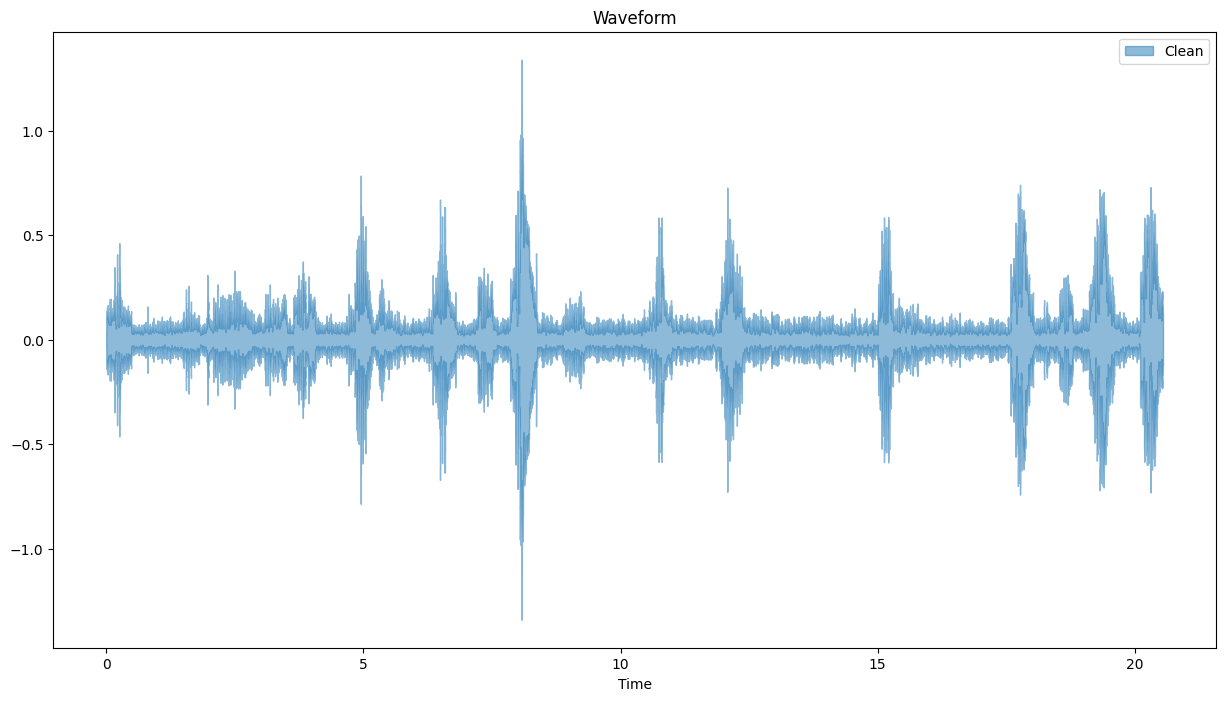

In [10]:
# 2. Time-Domain Analysis (Waveforms)
plt.figure(figsize=(15, 8))
# plt.subplot(3, 1, 1)
librosa.display.waveshow(y, sr=sr, alpha=0.5, label="Clean")
plt.title("Waveform")
plt.legend()

In [28]:
records = []
for _, row in caption_df.iterrows():
    # Match audio file from your list
    match = [f for f in audio_files if f.name == row["file_name"]]
    if match:
        records.append(
            {
                "file_name": row["file_name"],
                "audio": str(match[0]),  # HF needs string path
                "caption_1": row["caption_1"],
                "caption_2": row["caption_2"],
                "caption_3": row["caption_3"],
                "caption_4": row["caption_4"],
                "caption_5": row["caption_5"],
            }
        )

print(f"Matched: {len(records)} / {len(caption_df)}")

# --- Or if you also want metadata columns ---
# Merge captions + metadata first
merged_df = caption_df.merge(metadata_df, on="file_name", how="left")
merged_df = merged_df.dropna().reset_index(drop=True)

records = []
for _, row in merged_df.iterrows():
    match = [f for f in audio_files if f.name == row["file_name"]]
    if match:
        records.append(
            {
                "file_name": row["file_name"],
                "audio": str(match[0]),
                "caption_1": row["caption_1"],
                "caption_2": row["caption_2"],
                "caption_3": row["caption_3"],
                "caption_4": row["caption_4"],
                "caption_5": row["caption_5"],
                # Add any metadata columns you want
                "keywords": row.get("keywords", ""),
                "sound_id": row.get("sound_id", ""),
                "sound_link": row.get("sound_link", ""),
                "start_end_samples": row.get("start_end_samples", ""),
                "manufacturer": row.get("manufacturer", ""),
                "license": row.get("license", ""),
            }
        )

print(f"Matched: {len(records)} / {len(merged_df)}")

Matched: 3839 / 3839
Matched: 2648 / 2648


In [29]:
from datasets import Dataset, Audio

ds = Dataset.from_list(records)
ds = ds.cast_column("audio", Audio(sampling_rate=44100))

# Sample ~3GB worth
ds = ds.shuffle(seed=42).select(range(int(len(ds) * 3 / 7)))

ds_split = ds.train_test_split(test_size=0.2, seed=42)
ds_split.push_to_hub(
    "8Opt/clotho-dev-sample",
)

Uploading the dataset shards:   0%|          | 0/4 [00:00<?, ? shards/s]

Map:   0%|          | 0/227 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/8Opt/clotho-dev-sample/commit/bcca62424d3fe62fbaf390559892808bf61c69c4', commit_message='Upload dataset', commit_description='', oid='bcca62424d3fe62fbaf390559892808bf61c69c4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/8Opt/clotho-dev-sample', endpoint='https://huggingface.co', repo_type='dataset', repo_id='8Opt/clotho-dev-sample'), pr_revision=None, pr_num=None)

## Audio Augmentation

✅ Tier 1 (Always safe — use these):
   - SpecAugment (time + freq masking)
   - Light Gaussian noise (SNR > 15dB)
   - Random gain (±6dB)
   - Time shift
   - Polarity inversion
   - Mild speed perturbation (0.95–1.05x)

⚠️ Tier 2 (Use carefully):
   - Pitch shift (keep within ±1 semitone)
   - Speed perturbation (keep within 0.9–1.1x)
   - Mild reverb
   - Random crop (only if audio is longer than needed)

❌ Tier 3 (Avoid for retrieval):
   - Audio-only mixup (without mixing captions too)
   - Heavy background mixing
   - Extreme pitch/speed changes
   - Large time clipping


In [20]:
# --- Time Shifting ---
def time_shift(waveform, max_shift=0.2):
    """Shift audio left/right by a random amount"""
    shift = int(waveform.shape[-1] * random.uniform(-max_shift, max_shift))
    return torch.roll(waveform, shifts=shift, dims=-1)


# --- Speed Perturbation ---
def speed_perturb(waveform, sr, factor=None):
    """Change speed without changing pitch"""
    if factor is None:
        factor = random.choice([0.9, 0.95, 1.0, 1.05, 1.1])
    effects = [["speed", str(factor)], ["rate", str(sr)]]
    augmented, _ = torchaudio.sox_effects.apply_effects_tensor(waveform, sr, effects)
    return augmented


# --- Pitch Shifting ---
def pitch_shift(waveform, sr, n_steps=None):
    """Shift pitch up/down"""
    if n_steps is None:
        n_steps = random.uniform(-2, 2)
    return torchaudio.functional.pitch_shift(waveform, sr, n_steps)


# --- Add Gaussian Noise ---
def add_noise(waveform, snr_db=None):
    """Add random gaussian noise"""
    if snr_db is None:
        snr_db = random.uniform(10, 40)
    noise = torch.randn_like(waveform)
    signal_power = waveform.norm(p=2)
    noise_power = noise.norm(p=2)
    snr = 10 ** (snr_db / 20)
    scale = signal_power / (snr * noise_power)
    return waveform + scale * noise


# --- Random Gain ---
def random_gain(waveform, min_db=-6, max_db=6):
    """Randomly change volume"""
    gain_db = random.uniform(min_db, max_db)
    return waveform * (10 ** (gain_db / 20))


# --- Polarity Inversion ---
def polarity_inversion(waveform):
    """Flip the waveform"""
    return -waveform


# --- Random Crop / Pad ---
def random_crop(waveform, target_len):
    """Randomly crop a segment"""
    if waveform.shape[-1] > target_len:
        start = random.randint(0, waveform.shape[-1] - target_len)
        return waveform[..., start : start + target_len]
    else:
        # Pad with zeros
        pad = target_len - waveform.shape[-1]
        return torch.nn.functional.pad(waveform, (0, pad))


# --- Fade In / Fade Out ---
def fade(waveform, sr, fade_ms=50):
    """Apply fade in and fade out"""
    fade_samples = int(sr * fade_ms / 1000)
    fade_in = torch.linspace(0, 1, fade_samples)
    fade_out = torch.linspace(1, 0, fade_samples)
    waveform[..., :fade_samples] *= fade_in
    waveform[..., -fade_samples:] *= fade_out
    return waveform


# --- Time Clipping (Random Zero-out) ---
def time_clipping(waveform, max_clip_fraction=0.1):
    """Zero out a random chunk of audio"""
    clip_len = int(waveform.shape[-1] * random.uniform(0, max_clip_fraction))
    start = random.randint(0, waveform.shape[-1] - clip_len)
    waveform[..., start : start + clip_len] = 0
    return waveform

In [21]:
# --- SpecAugment: Time Masking ---
def time_mask(spec, max_mask=30):
    """Mask random time steps in spectrogram"""
    masking = T.TimeMasking(time_mask_param=max_mask)
    return masking(spec)


# --- SpecAugment: Frequency Masking ---
def freq_mask(spec, max_mask=20):
    """Mask random frequency bins in spectrogram"""
    masking = T.FrequencyMasking(freq_mask_param=max_mask)
    return masking(spec)


# --- Full SpecAugment (combine both) ---
def spec_augment(
    spec, n_time_masks=2, n_freq_masks=2, time_mask_param=30, freq_mask_param=20
):
    """Apply SpecAugment with multiple masks"""
    for _ in range(n_time_masks):
        spec = T.TimeMasking(time_mask_param)(spec)
    for _ in range(n_freq_masks):
        spec = T.FrequencyMasking(freq_mask_param)(spec)
    return spec


# --- Mixup (audio-level) ---
def mixup(waveform1, waveform2, alpha=0.3):
    """Mix two audio clips with a random ratio"""
    lam = np.random.beta(alpha, alpha)
    min_len = min(waveform1.shape[-1], waveform2.shape[-1])
    mixed = lam * waveform1[..., :min_len] + (1 - lam) * waveform2[..., :min_len]
    return mixed, lam


# --- Random Time Stretch (spectrogram) ---
def time_stretch(spec, rate=None):
    """Stretch/compress time axis of spectrogram"""
    if rate is None:
        rate = random.uniform(0.8, 1.2)
    stretch = T.TimeStretch()
    return stretch(spec, rate)


# --- FilterAugment (random band-pass filter) ---
def filter_augment(waveform, sr, low_freq=None, high_freq=None):
    """Apply random band-pass filter"""
    nyquist = sr // 2
    if low_freq is None:
        low_freq = random.randint(50, 500)
    if high_freq is None:
        high_freq = random.randint(4000, nyquist - 100)
    # Simple approach using torchaudio
    waveform = torchaudio.functional.highpass_biquad(waveform, sr, low_freq)
    waveform = torchaudio.functional.lowpass_biquad(waveform, sr, high_freq)
    return waveform

In [22]:
# --- Audio Mixup with Caption Mixup (for retrieval) ---
def audio_text_mixup(wav1, wav2, cap1, cap2, alpha=0.3):
    """Mix audio and concatenate captions"""
    lam = np.random.beta(alpha, alpha)
    min_len = min(wav1.shape[-1], wav2.shape[-1])
    mixed_audio = lam * wav1[..., :min_len] + (1 - lam) * wav2[..., :min_len]
    mixed_caption = f"{cap1} and {cap2}" if lam > 0.5 else f"{cap2} and {cap1}"
    return mixed_audio, mixed_caption, lam


# --- Random Reverb (using torchaudio RIR) ---
def add_reverb(waveform, rir):
    """Convolve with a room impulse response"""
    rir = rir / rir.norm(p=2)
    augmented = torch.nn.functional.conv1d(
        waveform.unsqueeze(0), rir.unsqueeze(0), padding=rir.shape[-1] - 1
    )
    return augmented.squeeze(0)[..., : waveform.shape[-1]]

## Text Augmentation

✅ Tier 1 (Always safe):
   - Back translation
   - Paraphrasing (T5 / LLM)
   - Synonym replacement (conservative, 1-2 words)
   - Template wrapping

⚠️ Tier 2 (Use with caution):
   - Light random deletion (p < 0.05, never delete negations)
   - Slight word reordering (adjacent swaps only)

❌ Tier 3 (Avoid):
   - Full shuffle
   - Heavy deletion
   - Random insertion of unrelated words


In [ ]:
def synonym_replace(sentence, n=2):
    """Replace n random words with synonyms"""
    words = sentence.split()
    new_words = words.copy()
    random_word_indices = random.sample(range(len(words)), min(n, len(words)))

    for idx in random_word_indices:
        synonyms = []
        for syn in wordnet.synsets(words[idx]):
            for lemma in syn.lemmas():
                if lemma.name() != words[idx]:
                    synonyms.append(lemma.name().replace("_", " "))
        if synonyms:
            new_words[idx] = random.choice(synonyms)
    return " ".join(new_words)


# --- Random Word Deletion ---
def random_deletion(sentence, p=0.1):
    """Randomly delete words with probability p"""
    words = sentence.split()
    if len(words) <= 1:
        return sentence
    remaining = [w for w in words if random.random() > p]
    return " ".join(remaining) if remaining else random.choice(words)


# --- Random Word Swap ---
def random_swap(sentence, n=2):
    """Randomly swap n pairs of words"""
    words = sentence.split()
    for _ in range(n):
        if len(words) >= 2:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
    return " ".join(words)


# --- Random Insertion ---
def random_insertion(sentence, n=1):
    """Insert n random synonyms at random positions"""
    words = sentence.split()
    for _ in range(n):
        word = random.choice(words)
        synonyms = []
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                if lemma.name() != word:
                    synonyms.append(lemma.name().replace("_", " "))
        if synonyms:
            words.insert(random.randint(0, len(words)), random.choice(synonyms))
    return " ".join(words)


# --- Shuffle Words (keep some structure) ---
def shuffle_middle(sentence):
    """Keep first and last word, shuffle the rest"""
    words = sentence.split()
    if len(words) <= 3:
        return sentence
    middle = words[1:-1]
    random.shuffle(middle)
    return " ".join([words[0]] + middle + [words[-1]])

In [ ]:
# --- Back Translation (using pre-trained models) ---
from transformers import MarianMTModel, MarianTokenizer


def back_translate(text, src="en", pivot="de"):
    """Translate to another language and back"""
    # en -> pivot
    fwd_name = f"Helsinki-NLP/opus-mt-{src}-{pivot}"
    fwd_tok = MarianTokenizer.from_pretrained(fwd_name)
    fwd_model = MarianMTModel.from_pretrained(fwd_name)

    encoded = fwd_tok(text, return_tensors="pt", padding=True, truncation=True)
    translated = fwd_model.generate(**encoded)
    pivot_text = fwd_tok.decode(translated[0], skip_special_tokens=True)

    # pivot -> en
    bwd_name = f"Helsinki-NLP/opus-mt-{pivot}-{src}"
    bwd_tok = MarianTokenizer.from_pretrained(bwd_name)
    bwd_model = MarianMTModel.from_pretrained(bwd_name)

    encoded = bwd_tok(pivot_text, return_tensors="pt", padding=True, truncation=True)
    back = bwd_model.generate(**encoded)
    return bwd_tok.decode(back[0], skip_special_tokens=True)


# Example:
# "A dog barks loudly in the park"
#   -> German -> "Ein Hund bellt laut im Park"
#   -> English -> "A dog is barking loudly in the park"

In [ ]:
# --- Paraphrase with T5 ---
from transformers import T5ForConditionalGeneration, T5Tokenizer


def paraphrase_t5(text, num_variants=3):
    """Generate paraphrases using T5"""
    tokenizer = T5Tokenizer.from_pretrained("Vamsi/T5_Paraphrase_Paws")
    model = T5ForConditionalGeneration.from_pretrained("Vamsi/T5_Paraphrase_Paws")

    input_text = f"paraphrase: {text} </s>"
    encoded = tokenizer.encode(
        input_text, return_tensors="pt", max_length=128, truncation=True
    )

    outputs = model.generate(
        encoded,
        max_length=128,
        num_beams=num_variants + 2,
        num_return_sequences=num_variants,
        temperature=1.5,
    )
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

In [ ]:
class AudioAugmentor:
    """Safe audio augmentations for audio-text retrieval."""

    def __init__(self, sr: int = 44100):
        self.sr = sr
        self.augmentations = [
            self.add_noise,
            self.random_gain,
            self.time_shift,
            self.polarity_inversion,
            self.speed_perturb,
            self.spec_augment_on_waveform,
        ]

    def __call__(self, waveform: torch.Tensor) -> torch.Tensor:
        # Apply 1-3 random augmentations
        n_augs = random.randint(1, 3)
        chosen = random.sample(self.augmentations, min(n_augs, len(self.augmentations)))
        for aug in chosen:
            waveform = aug(waveform)
        return waveform

    def add_noise(self, waveform, snr_db_range=(15, 40)):
        snr_db = random.uniform(*snr_db_range)
        noise = torch.randn_like(waveform)
        signal_power = waveform.norm(p=2)
        noise_power = noise.norm(p=2)
        if noise_power == 0:
            return waveform
        scale = signal_power / (10 ** (snr_db / 20) * noise_power)
        return waveform + scale * noise

    def random_gain(self, waveform, min_db=-6, max_db=6):
        gain_db = random.uniform(min_db, max_db)
        return waveform * (10 ** (gain_db / 20))

    def time_shift(self, waveform, max_shift=0.1):
        shift = int(waveform.shape[-1] * random.uniform(-max_shift, max_shift))
        return torch.roll(waveform, shifts=shift, dims=-1)

    def polarity_inversion(self, waveform):
        return -waveform if random.random() > 0.5 else waveform

    def speed_perturb(self, waveform, factor_range=(0.95, 1.05)):
        factor = random.uniform(*factor_range)
        resampled = torchaudio.functional.resample(
            waveform, orig_freq=self.sr, new_freq=int(self.sr * factor)
        )
        return resampled

    def spec_augment_on_waveform(self, waveform):
        """Apply small random zero-out segments (simplified SpecAugment on waveform)."""
        clip_fraction = random.uniform(0.0, 0.05)
        clip_len = int(waveform.shape[-1] * clip_fraction)
        if clip_len > 0:
            start = random.randint(0, waveform.shape[-1] - clip_len)
            waveform = waveform.clone()
            waveform[..., start : start + clip_len] = 0
        return waveform


class TextAugmentor:
    """Safe text augmentations for audio-text retrieval (meaning-preserving)."""

    def __init__(self):
        self.templates = [
            "{caption}",
            "The sound of {caption_lower}",
            "Audio recording of {caption_lower}",
            "A clip where {caption_lower}",
            "You can hear {caption_lower}",
            "An audio where {caption_lower}",
        ]

    def __call__(self, caption: str) -> str:
        # Apply one random text augmentation
        aug = random.choice(
            [
                self.template_wrap,
                self.light_synonym_replace,
                self.identity,
            ]
        )
        return aug(caption)

    def identity(self, caption):
        return caption

    def template_wrap(self, caption):
        template = random.choice(self.templates)
        return template.format(caption=caption, caption_lower=caption.lower())

    def light_synonym_replace(self, caption, n=1):
        """Replace 1 word with a simple synonym (no NLTK dependency)."""
        # Lightweight synonyms for common audio description words
        synonyms = {
            "loud": ["noisy", "blaring"],
            "quiet": ["soft", "gentle"],
            "fast": ["quick", "rapid"],
            "slow": ["unhurried", "gradual"],
            "big": ["large", "huge"],
            "small": ["tiny", "little"],
            "many": ["several", "numerous"],
            "walks": ["strolls", "steps"],
            "runs": ["jogs", "sprints"],
            "talks": ["speaks", "chats"],
            "sings": ["vocalizes", "chants"],
            "plays": ["performs"],
            "hits": ["strikes", "taps"],
            "falls": ["drops", "descends"],
            "moves": ["shifts", "travels"],
            "flows": ["streams", "runs"],
            "blows": ["gusts", "whooshes"],
        }
        words = caption.split()
        replaced = False
        indices = list(range(len(words)))
        random.shuffle(indices)
        for idx in indices:
            word_lower = words[idx].lower().strip(".,!?")
            if word_lower in synonyms and not replaced:
                replacement = random.choice(synonyms[word_lower])
                # Preserve original casing roughly
                if words[idx][0].isupper():
                    replacement = replacement.capitalize()
                words[idx] = replacement
                replaced = True
                break
        return " ".join(words)


class ClothoDataset(Dataset):
    """
    Clotho dataset for Language-Based Audio Retrieval.

    Compatible with HuggingFace Trainer — returns a dict from __getitem__.

    Args:
        audio_dir:       Path to the directory containing .wav files
        captions_csv:    Path to the captions CSV file
        audio_processor: A callable that processes raw waveform into model inputs
                         (e.g., ClapProcessor, Wav2Vec2Processor, or a mel-spec transform)
        text_tokenizer:  A callable tokenizer (e.g., AutoTokenizer)
        sr:              Target sample rate
        max_audio_len:   Max audio length in seconds (clips/pads to this)
        train:           If True, apply augmentations
        text_max_length: Max token length for text
    """

    def __init__(
        self,
        audio_dir: str,
        captions_csv: str,
        audio_processor: Optional[Callable] = None,
        text_tokenizer: Optional[Callable] = None,
        sr: int = 44100,
        max_audio_len: float = 30.0,
        train: bool = True,
        text_max_length: int = 77,
    ):
        self.audio_dir = audio_dir
        self.sr = sr
        self.max_audio_len = max_audio_len
        self.max_samples = int(sr * max_audio_len)
        self.train = train
        self.audio_processor = audio_processor
        self.text_tokenizer = text_tokenizer
        self.text_max_length = text_max_length

        # Load captions and melt into (file_name, caption) pairs
        captions_df = pd.read_csv(captions_csv)
        caption_cols = [c for c in captions_df.columns if c.startswith("caption")]

        self.data = captions_df.melt(
            id_vars=["file_name"],
            value_vars=caption_cols,
            var_name="caption_number",
            value_name="caption",
        ).reset_index(drop=True)

        # Drop any rows with missing captions
        self.data = self.data.dropna(subset=["caption"]).reset_index(drop=True)

        # Augmentors (only used in train mode)
        self.audio_augmentor = AudioAugmentor(sr=sr) if train else None
        self.text_augmentor = TextAugmentor() if train else None

    def __len__(self) -> int:
        return len(self.data)

    def _load_audio(self, file_name: str) -> torch.Tensor:
        """Load and preprocess audio to a fixed length."""
        path = os.path.join(self.audio_dir, file_name)
        waveform, orig_sr = torchaudio.load(path)

        # Resample if needed
        if orig_sr != self.sr:
            waveform = torchaudio.functional.resample(waveform, orig_sr, self.sr)

        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Pad or truncate to max_samples
        if waveform.shape[-1] > self.max_samples:
            # Random crop during training, center crop during eval
            if self.train:
                start = random.randint(0, waveform.shape[-1] - self.max_samples)
            else:
                start = (waveform.shape[-1] - self.max_samples) // 2
            waveform = waveform[..., start : start + self.max_samples]
        elif waveform.shape[-1] < self.max_samples:
            pad_len = self.max_samples - waveform.shape[-1]
            waveform = torch.nn.functional.pad(waveform, (0, pad_len))

        return waveform  # shape: (1, max_samples)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.data.iloc[idx]
        file_name = row["file_name"]
        caption = row["caption"]

        # --- Load audio ---
        waveform = self._load_audio(file_name)

        # --- Audio augmentation (train only) ---
        if self.train and self.audio_augmentor:
            waveform = self.audio_augmentor(waveform)

        # --- Text augmentation (train only) ---
        if self.train and self.text_augmentor:
            caption = self.text_augmentor(caption)

        # --- Process audio through processor (e.g., CLAP, mel-spec) ---
        if self.audio_processor is not None:
            audio_inputs = self.audio_processor(
                audios=waveform.squeeze(0).numpy(),
                sampling_rate=self.sr,
                return_tensors="pt",
                padding="max_length",
                max_length=self.max_samples,
            )
            # Flatten batch dim added by processor
            audio_inputs = {k: v.squeeze(0) for k, v in audio_inputs.items()}
        else:
            # Return raw waveform if no processor
            audio_inputs = {"input_values": waveform.squeeze(0)}

        # --- Tokenize text ---
        if self.text_tokenizer is not None:
            text_inputs = self.text_tokenizer(
                caption,
                padding="max_length",
                max_length=self.text_max_length,
                truncation=True,
                return_tensors="pt",
            )
            # Flatten batch dim
            text_inputs = {k: v.squeeze(0) for k, v in text_inputs.items()}
        else:
            text_inputs = {"caption": caption}

        # --- Combine into a single dict (HF Trainer compatible) ---
        output = {}
        output.update(audio_inputs)
        output["input_ids"] = text_inputs.get("input_ids", caption)
        output["attention_mask"] = text_inputs.get(
            "attention_mask",
            torch.ones_like(text_inputs.get("input_ids", torch.tensor([]))),
        )

        return output

In [ ]:
# ============================================================
# Usage Examples
# ============================================================

# --- Example 1: With CLAP processor ---
"""
from transformers import ClapProcessor

processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

train_dataset = ClothoDataset(
    audio_dir="path/to/clotho/development",
    captions_csv="path/to/clotho_captions_development.csv",
    audio_processor=processor.feature_extractor,
    text_tokenizer=processor.tokenizer,
    sr=48000,
    train=True,
)

val_dataset = ClothoDataset(
    audio_dir="path/to/clotho/validation",
    captions_csv="path/to/clotho_captions_validation.csv",
    audio_processor=processor.feature_extractor,
    text_tokenizer=processor.tokenizer,
    sr=48000,
    train=False,  # No augmentation
)

# Use with HF Trainer
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    num_train_epochs=10,
    ...
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

trainer.train()
"""

# --- Example 2: With custom mel-spectrogram (no HF processor) ---
"""
train_dataset = ClothoDataset(
    audio_dir="path/to/clotho/development",
    captions_csv="path/to/clotho_captions_development.csv",
    audio_processor=None,   # raw waveform
    text_tokenizer=None,    # raw caption string
    sr=44100,
    train=True,
)

sample = train_dataset[0]
print(sample["input_values"].shape)  # (max_samples,)
print(sample["caption"])             # "A dog barks in the park"
"""

In [ ]:
import torch
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments
from dataclasses import dataclass
from typing import Optional, Dict


# ============================================================
# 1. Custom Loss (same InfoNCE as before)
# ============================================================


class InfoNCELoss(torch.nn.Module):
    def __init__(self, temperature=0.07, learnable_temp=True):
        super().__init__()
        if learnable_temp:
            self.temperature = torch.nn.Parameter(torch.tensor([temperature]).log())
        else:
            self.register_buffer("temperature", torch.tensor([temperature]).log())

    def forward(self, audio_embeds, text_embeds):
        temp = self.temperature.exp().clamp(max=100.0)
        logits = (audio_embeds @ text_embeds.T) * temp
        labels = torch.arange(logits.shape[0], device=logits.device)
        loss_a2t = F.cross_entropy(logits, labels)
        loss_t2a = F.cross_entropy(logits.T, labels)
        return (loss_a2t + loss_t2a) / 2.0


# ============================================================
# 2. Custom Trainer
# ============================================================


class CLAPTrainer(Trainer):
    """
    Custom HuggingFace Trainer for audio-text contrastive learning.

    Override points:
      - compute_loss()     → custom InfoNCE loss
      - evaluation_loop()  → custom retrieval metrics (R@K)
      - create_optimizer() → separate param groups if needed
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Attach custom loss (moves to correct device automatically)
        self.criterion = InfoNCELoss(temperature=0.07, learnable_temp=True)
        self.criterion.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Override the default compute_loss to use contrastive loss.

        This is the MAIN method to override — Trainer calls this
        for every training step.
        """
        # Extract audio & text inputs
        input_values = inputs["input_values"]
        input_ids = inputs["input_ids"]
        attention_mask = inputs["attention_mask"]

        # Forward pass — get embeddings
        audio_embeds = model.get_audio_features(input_features=input_values)
        text_embeds = model.get_text_features(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        # L2 normalize
        audio_embeds = F.normalize(audio_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        # Compute loss
        loss = self.criterion(audio_embeds, text_embeds)

        if return_outputs:
            return loss, {"audio_embeds": audio_embeds, "text_embeds": text_embeds}
        return loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        """
        Override to return embeddings during evaluation.

        Trainer calls this for each eval batch. We return embeddings
        so we can compute R@K on the full eval set.
        """
        model.eval()
        with torch.no_grad():
            input_values = inputs["input_values"].to(self.args.device)
            input_ids = inputs["input_ids"].to(self.args.device)
            attention_mask = inputs["attention_mask"].to(self.args.device)

            audio_embeds = model.get_audio_features(input_features=input_values)
            text_embeds = model.get_text_features(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            audio_embeds = F.normalize(audio_embeds, dim=-1)
            text_embeds = F.normalize(text_embeds, dim=-1)

            loss = self.criterion(audio_embeds, text_embeds)

        if prediction_loss_only:
            return (loss, None, None)

        # Pack both embeddings into "logits" — we'll unpack in compute_metrics
        # Shape: (batch, 2, embed_dim) → Trainer will concat along batch dim
        stacked = torch.stack([audio_embeds, text_embeds], dim=1)

        # Labels are just indices (diagonal = positive pairs)
        labels = torch.arange(audio_embeds.shape[0], device=audio_embeds.device)

        return (loss, stacked, labels)

    def create_optimizer(self):
        """
        Override to add the criterion's learnable temperature
        to the optimizer param groups.
        """
        # Get default optimizer params from the model
        decay_params = []
        no_decay_params = []

        for name, param in self.model.named_parameters():
            if not param.requires_grad:
                continue
            if "bias" in name or "LayerNorm" in name or "layernorm" in name:
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        optimizer_grouped = [
            {"params": decay_params, "weight_decay": self.args.weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
            {
                "params": self.criterion.parameters(),
                "lr": self.args.learning_rate,
                "weight_decay": 0.0,
            },
        ]

        self.optimizer = torch.optim.AdamW(
            optimizer_grouped, lr=self.args.learning_rate
        )
        return self.optimizer


# ============================================================
# 3. Custom Metrics
# ============================================================


def compute_retrieval_metrics(eval_pred):
    """
    Compute Recall@K from the stacked embeddings.

    This function is passed to Trainer(compute_metrics=...).
    Trainer calls it after gathering all prediction_step outputs.
    """
    stacked_embeds, labels = eval_pred  # stacked_embeds: (N, 2, D)

    stacked_embeds = torch.tensor(stacked_embeds)
    audio_embeds = stacked_embeds[:, 0, :]  # (N, D)
    text_embeds = stacked_embeds[:, 1, :]  # (N, D)

    # Similarity matrix
    sim = audio_embeds @ text_embeds.T  # (N, N)
    N = sim.shape[0]
    gt = torch.arange(N)

    metrics = {}

    for prefix, sims in [("A2T", sim), ("T2A", sim.T)]:
        ranks = sims.argsort(dim=1, descending=True)
        for k in [1, 5, 10]:
            correct = (ranks[:, :k] == gt.unsqueeze(1)).any(dim=1).float()
            metrics[f"{prefix}_R@{k}"] = correct.mean().item() * 100

    metrics["mR"] = sum(metrics.values()) / len(metrics)

    return metrics


# ============================================================
# 4. Collate Function
# ============================================================


def collate_fn(batch):
    collated = {}
    for key in batch[0].keys():
        values = [item[key] for item in batch]
        if isinstance(values[0], torch.Tensor):
            collated[key] = torch.stack(values)
        else:
            collated[key] = values
    return collated


# ============================================================
# 5. Put It All Together
# ============================================================

"""
from transformers import ClapModel, ClapProcessor

# Model & Processor
model_name = "laion/clap-htsat-unfused"
processor = ClapProcessor.from_pretrained(model_name)
model = ClapModel.from_pretrained(model_name)

# Datasets (using ClothoDataset from before)
train_dataset = ClothoDataset(
    audio_dir="path/to/clotho/development",
    captions_csv="path/to/clotho_captions_development.csv",
    audio_processor=processor.feature_extractor,
    text_tokenizer=processor.tokenizer,
    sr=48000,
    train=True,
)

val_dataset = ClothoDataset(
    audio_dir="path/to/clotho/validation",
    captions_csv="path/to/clotho_captions_validation.csv",
    audio_processor=processor.feature_extractor,
    text_tokenizer=processor.tokenizer,
    sr=48000,
    train=False,
)

# Training Arguments — all the HF goodies for free
training_args = TrainingArguments(
    output_dir="./results",
    
    # Training
    num_train_epochs=20,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,       # effective batch = 64
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    fp16=True,
    max_grad_norm=1.0,
    dataloader_drop_last=True,           # important for contrastive loss
    
    # Evaluation
    eval_strategy="epoch",
    metric_for_best_model="mR",
    greater_is_better=True,
    load_best_model_at_end=True,
    
    # Saving
    save_strategy="epoch",
    save_total_limit=3,
    
    # Logging
    logging_steps=10,
    report_to="wandb",                   # or "tensorboard", "none"
    run_name="clap-clotho-finetune",
    
    # Misc
    dataloader_num_workers=4,
    seed=42,
)

# Create Custom Trainer
trainer = CLAPTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_retrieval_metrics,
)

# Train!
trainer.train()

# Save final model
trainer.save_model("./final_model")
"""